# E-Commerce Sales & Customer Analytics

Dataset: a synthetic e-commerce transactions dataset (18,000+ orders, 2023-2024) built to look like a real online retail export. I generated it myself for this portfolio project, so it's not real company data, but the patterns (seasonality, category margins, repeat customers) are modeled realistically.

Goal: clean the raw export, dig into sales/profit/customer patterns, and pull out insights I could actually present to a business stakeholder.

## Part 1: Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

RAW_PATH = "../data/raw/ecommerce_raw.csv"
df = pd.read_csv(RAW_PATH)
df.shape

(18150, 18)

In [2]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product_ID,Product_Name,Category,Sub_Category,Region,State,Quantity,Unit_Price,Sales,Discount,Cost,Profit,Payment_Mode,Customer_Type
0,ORD117710,2023-03-30,CUST00524,Ayaan Reddy,PRD-BEA-018,Lipstick Pro 18,Beauty,Lipstick,South,Tamil Nadu,1,2819.57,2819.57,0.10,1476.58,1061.03,UPI,Returning
1,ORD115123,2023-12-31,CUST02098,Myra Das,PRD-BOO-010,Comic Book Elite 10,Books,Comic Book,South,Tamil Nadu,1,1127.78,1127.78,0.20,762.64,139.58,Debit Card,New
2,ORD103902,2024-04-01,CUST00902,Vivaan Patel,PRD-ELE-007,Headphones Lite 7,Electronics,Headphones,South,Karnataka,5,29019.26,145096.30,0.00,116053.10,29043.20,UPI,Returning
3,ORD116226,2023-06-15,CUST02241,Ayaan Pillai,PRD-SPO-001,Running Shoes Air 1,Sports,Running Shoes,West,Gujarat,2,4959.27,9918.54,0.15,6166.76,2264.00,Net Banking,Returning
4,ORD113790,2023-01-16,CUST02229,Ayaan Agarwal,PRD-FAS-015,T-Shirt Classic 15,Fashion,T-Shirt,North,Delhi,1,3459.61,3459.61,0.05,1827.82,1458.81,UPI,Returning


Before touching any values I want to check the shape, column types, and a quick statistical summary. Dates and numbers usually get loaded as plain text (`object`), so I need to know that before doing any date math or arithmetic later.

In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)

Shape: (18150, 18)

Columns: ['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'State', 'Quantity', 'Unit_Price', 'Sales', 'Discount', 'Cost', 'Profit', 'Payment_Mode', 'Customer_Type']

Data types:
 Order_ID             str
Order_Date           str
Customer_ID          str
Customer_Name        str
Product_ID           str
Product_Name         str
Category             str
Sub_Category         str
Region               str
State                str
Quantity           int64
Unit_Price       float64
Sales            float64
Discount         float64
Cost             float64
Profit           float64
Payment_Mode         str
Customer_Type        str
dtype: object


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,18150,18000,ORD100206,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,18150,732,2024-11-01,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,18150,4147,CUST02792,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,17969,400,Diya Nair,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,18150,180,PRD-BOO-012,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,18150,180,Textbook Elite 12,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,18150,12,Beauty,3137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub_Category,18150,32,Cycling Helmet,1085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,18150,4,East,4628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,17969,16,Punjab,1175,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Part 2: Checking data quality

### Missing values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report[missing_report.missing_count > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
Discount,362,1.99
Payment_Mode,271,1.49
State,181,1.00
Customer_Name,181,1.00


### Duplicate records

In [6]:
dupe_count = df.duplicated().sum()
print(f"Fully duplicate rows: {dupe_count}")

# a single order should only show up once, so check duplicate Order_IDs too
dupe_orders = df.duplicated(subset=["Order_ID"]).sum()
print(f"Duplicate Order_IDs: {dupe_orders}")

Fully duplicate rows: 150
Duplicate Order_IDs: 150


### Invalid values

In [7]:
print("Rows with non-positive Quantity:", (df.Quantity <= 0).sum())
print("Rows with Unit_Price == 0:", (df.Unit_Price == 0).sum())
print("Distinct Category values (checking for inconsistent casing):")
print(df.Category.unique())

Rows with non-positive Quantity: 20
Rows with Unit_Price == 0: 20
Distinct Category values (checking for inconsistent casing):
<StringArray>
[        'Beauty',          'Books',    'Electronics',         'Sports',
        'Fashion', 'Home & Kitchen',        'FASHION',         'SPORTS',
         'BEAUTY',    'ELECTRONICS', 'HOME & KITCHEN',          'BOOKS']
Length: 12, dtype: str


## Part 3: Cleaning the data

My plan here:
1. Drop exact duplicate rows. These look like double-submitted orders, and keeping them would double-count revenue.
2. Fix inconsistent text casing in `Category` (e.g. `"ELECTRONICS"` and `"Electronics"` should be the same bucket).
3. Drop rows where `Quantity` is 0 or negative, or `Unit_Price` is 0. These are data entry errors, not real sales, and would mess up revenue/profit totals if left in.
4. Fix the malformed date strings, then convert `Order_Date` to an actual datetime.
5. Fill in missing text fields with `"Unknown"` instead of dropping the whole row, since the rest of the row is still valid sales data.
6. Fill missing `Discount` with 0.

In [8]:
df_clean = df.copy()

# 1. drop exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows")

# 2. fix category casing
df_clean["Category"] = df_clean["Category"].str.strip().str.title()

# 3. drop invalid quantity / price rows
before = len(df_clean)
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Unit_Price"] > 0)]
print(f"Dropped {before - len(df_clean)} rows with invalid Quantity/Unit_Price")

# 4. fix malformed dates, then convert to datetime
df_clean["Order_Date"] = df_clean["Order_Date"].replace("0000-00-00", np.nan)
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Order_Date"])
print(f"Dropped {before - len(df_clean)} rows with malformed/missing Order_Date")
df_clean["Order_Date"] = pd.to_datetime(df_clean["Order_Date"])

# 5 & 6. fill remaining missing values
df_clean["Customer_Name"] = df_clean["Customer_Name"].fillna("Unknown")
df_clean["Payment_Mode"] = df_clean["Payment_Mode"].fillna("Unknown")
df_clean["State"] = df_clean["State"].fillna("Unknown")
df_clean["Discount"] = df_clean["Discount"].fillna(0)

print("\nRemaining missing values:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)

Dropped 150 duplicate rows
Dropped 40 rows with invalid Quantity/Unit_Price
Dropped 25 rows with malformed/missing Order_Date



Remaining missing values: 0
Final shape: (17935, 18)


Now adding a few calculated columns that make the rest of the analysis easier.

In [9]:
df_clean["Revenue"] = (df_clean["Sales"] * (1 - df_clean["Discount"])).round(2)
df_clean["Profit_Margin"] = (df_clean["Profit"] / df_clean["Revenue"]).round(4)
df_clean["Month"] = df_clean["Order_Date"].dt.to_period("M").astype(str)
df_clean["Quarter"] = df_clean["Order_Date"].dt.to_period("Q").astype(str)
df_clean["Year"] = df_clean["Order_Date"].dt.year

df_clean[["Order_Date","Sales","Discount","Revenue","Cost","Profit","Profit_Margin","Month","Quarter","Year"]].head()

,Order_Date,Sales,Discount,Revenue,Cost,Profit,Profit_Margin,Month,Quarter,Year
0,2023-03-30,2819.57,0.10,2537.61,1476.58,1061.03,0.4181,2023-03,2023Q1,2023
1,2023-12-31,1127.78,0.20,902.22,762.64,139.58,0.1547,2023-12,2023Q4,2023
2,2024-04-01,145096.30,0.00,145096.30,116053.10,29043.20,0.2002,2024-04,2024Q2,2024
3,2023-06-15,9918.54,0.15,8430.76,6166.76,2264.00,0.2685,2023-06,2023Q2,2023
4,2023-01-16,3459.61,0.05,3286.63,1827.82,1458.81,0.4439,2023-01,2023Q1,2023


Quick outlier check using IQR. I'm not deleting anything here though, since a big Revenue value could just be a legit bulk order, not bad data.

In [10]:
Q1, Q3 = df_clean["Revenue"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df_clean[(df_clean["Revenue"] < lower) | (df_clean["Revenue"] > upper)]
print(f"Potential Revenue outliers: {len(outliers)} rows ({len(outliers)/len(df_clean)*100:.2f}% of data)")

Potential Revenue outliers: 2387 rows (13.31% of data)


In [11]:
df_clean.to_csv("../data/cleaned/ecommerce_cleaned.csv", index=False)
print("Saved cleaned dataset:", df_clean.shape)

Saved cleaned dataset: (17935, 23)


## Part 4: EDA

### KPIs first

In [12]:
total_revenue = df_clean["Revenue"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = df_clean["Order_ID"].nunique()
total_customers = df_clean["Customer_ID"].nunique()
avg_order_value = total_revenue / total_orders
overall_margin = total_profit / total_revenue

print(f"Total Revenue      : Rs {total_revenue:,.0f}")
print(f"Total Profit       : Rs {total_profit:,.0f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Avg Order Value    : Rs {avg_order_value:,.2f}")
print(f"Overall Profit Margin: {overall_margin*100:.2f}%")

Total Revenue      : Rs 231,483,433
Total Profit       : Rs 43,720,668
Total Orders       : 17,935
Total Customers    : 4,147
Avg Order Value    : Rs 12,906.80
Overall Profit Margin: 18.89%


### Monthly revenue and profit trend

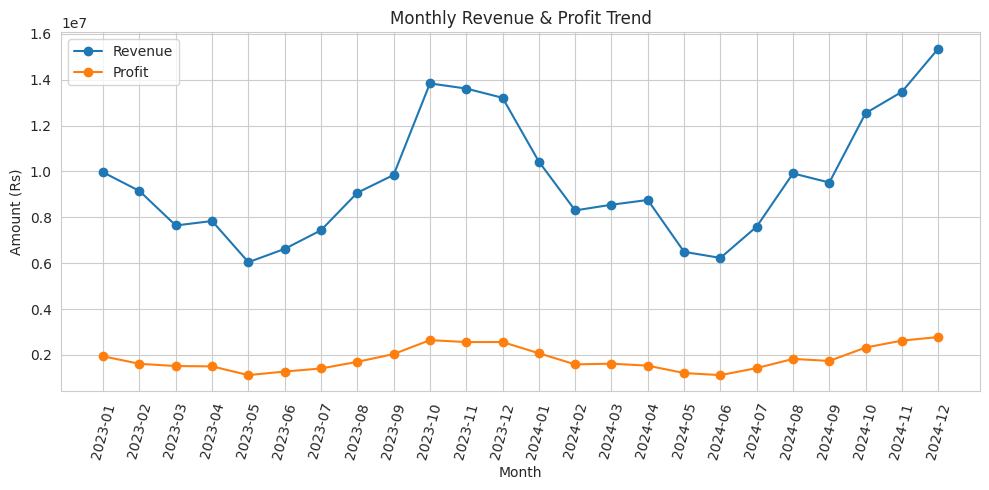

In [13]:
monthly = df_clean.groupby("Month")[["Revenue","Profit"]].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(monthly["Month"], monthly["Revenue"], marker="o", label="Revenue")
ax.plot(monthly["Month"], monthly["Profit"], marker="o", label="Profit")
ax.set_title("Monthly Revenue & Profit Trend")
ax.set_xlabel("Month"); ax.set_ylabel("Amount (Rs)")
plt.xticks(rotation=75)
ax.legend()
plt.tight_layout()
plt.show()

Revenue climbs from October through December, which lines up with festive/holiday season shopping, then dips again around May-June. Makes sense to plan inventory and ad spend around that Q4 spike instead of spreading budget evenly across the year.

### Category and sub-category performance

In [14]:
cat_perf = df_clean.groupby("Category")[["Revenue","Profit"]].sum().sort_values("Revenue", ascending=False)
cat_perf["Profit_Margin_%"] = (cat_perf["Profit"]/cat_perf["Revenue"]*100).round(2)
cat_perf

,Revenue,Profit,Profit_Margin_%
Category,,,
Electronics,1.451810e+08,17408309.42,11.99
Home & Kitchen,4.236759e+07,10824484.35,25.55
Sports,1.981934e+07,6203434.46,31.30
Fashion,1.348735e+07,5268816.36,39.06
Beauty,7.179340e+06,3221732.09,44.88
Books,3.448792e+06,793891.72,23.02


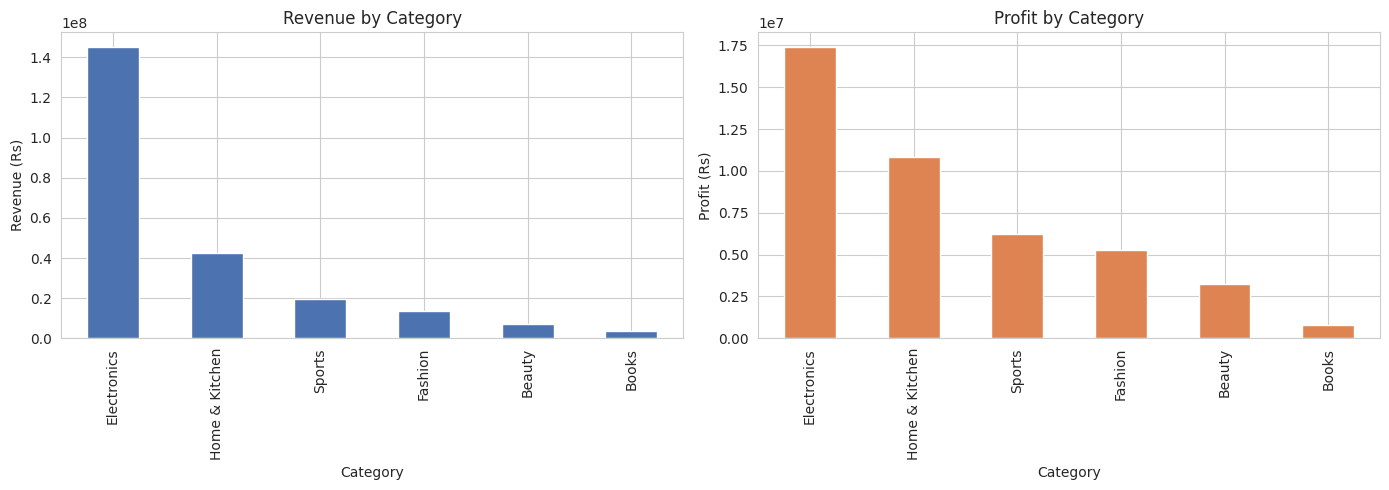

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cat_perf["Revenue"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Revenue by Category")
axes[0].set_ylabel("Revenue (Rs)")

cat_perf["Profit"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Profit by Category")
axes[1].set_ylabel("Profit (Rs)")
plt.tight_layout()
plt.show()

The category bringing in the most revenue isn't automatically the most profitable one. Worth checking `Profit_Margin_%` alongside `Revenue` here, since a high-revenue/low-margin category is a candidate for pricing review, and a high-margin one is worth pushing harder in marketing.

### Top and bottom 10 products

In [16]:
product_perf = df_clean.groupby(["Product_ID","Product_Name"])[["Revenue","Profit","Quantity"]].sum()

top10 = product_perf.sort_values("Revenue", ascending=False).head(10)
bottom10 = product_perf[product_perf["Quantity"]>0].sort_values("Revenue", ascending=True).head(10)

print("Top 10 products by revenue"); display(top10)
print("\nBottom 10 products by revenue"); display(bottom10)

Top 10 products by revenue


,,Revenue,Profit,Quantity
Product_ID,Product_Name,,,
PRD-ELE-011,Smartphone Classic 11,10567042.31,1209506.73,210
PRD-ELE-009,Smartphone Classic 9,9276883.80,1175690.03,186
PRD-ELE-010,Smartwatch Classic 10,9112249.72,1160249.39,182
PRD-ELE-021,Smartwatch Lite 21,8625840.82,1043319.21,169
PRD-ELE-023,Tablet Basic 23,8419549.96,1047079.00,169
PRD-ELE-026,Headphones Max 26,8230957.15,948567.58,207
PRD-ELE-001,Smartwatch Pro 1,7736966.98,926259.83,166
PRD-ELE-008,Tablet Air 8,7548441.30,796634.03,151
PRD-ELE-004,Smartwatch Pro 4,6283402.16,747920.73,198



Bottom 10 products by revenue


,,Revenue,Profit,Quantity
Product_ID,Product_Name,,,
PRD-BEA-008,Lipstick Basic 8,28776.84,12769.52,188
PRD-BOO-009,Comic Book Basic 9,33461.16,6884.65,228
PRD-BEA-020,Sunscreen Basic 20,51542.13,23566.86,180
PRD-BOO-028,Cookbook Basic 28,51677.25,12151.62,189
PRD-BOO-007,Cookbook Pro 7,53663.32,12466.74,177
PRD-BEA-025,Sunscreen Basic 25,54770.78,24954.50,216
PRD-FAS-002,Sunglasses Elite 2,62845.14,24024.47,130
PRD-BOO-011,Self-Help Book Elite 11,70207.99,16471.19,148
PRD-BOO-012,Textbook Elite 12,73545.70,17398.33,233


### Regional performance

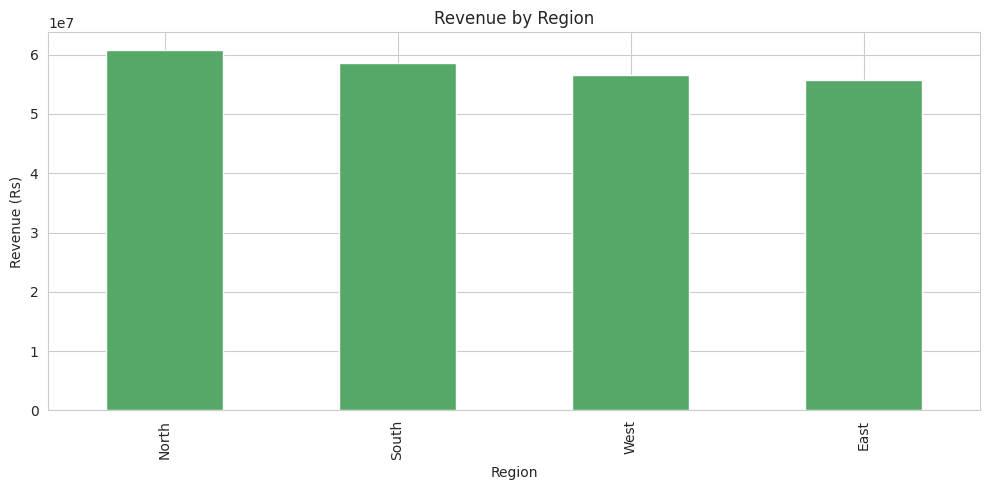

,Revenue,Profit,Profit_Margin_%
Region,,,
North,60723672.96,11312353.13,18.63
South,58524381.19,11069764.18,18.91
West,56560138.27,10694159.03,18.91
East,55675240.76,10644392.06,19.12


In [17]:
region_perf = df_clean.groupby("Region")[["Revenue","Profit"]].sum().sort_values("Revenue", ascending=False)
region_perf["Profit_Margin_%"] = (region_perf["Profit"]/region_perf["Revenue"]*100).round(2)

region_perf["Revenue"].plot(kind="bar", color="#55A868", title="Revenue by Region")
plt.ylabel("Revenue (Rs)")
plt.tight_layout()
plt.show()
region_perf

Whichever region tops this list is carrying a bigger share of revenue than the rest. If one region is clearly behind, that's a signal to look at marketing spend or delivery/logistics issues there.

### New vs returning customers

In [18]:
cust_type_perf = df_clean.groupby("Customer_Type")[["Revenue","Profit"]].sum()
order_counts = df_clean.groupby("Customer_Type")["Order_ID"].nunique()
cust_type_perf["Orders"] = order_counts
cust_type_perf["AOV"] = (cust_type_perf["Revenue"]/cust_type_perf["Orders"]).round(2)
cust_type_perf

,Revenue,Profit,Orders,AOV
Customer_Type,,,,
New,9.638316e+07,18400421.27,7491,12866.53
Returning,1.351003e+08,25320247.13,10444,12935.68


### Discount vs profit
Does discounting harder actually hurt margin?

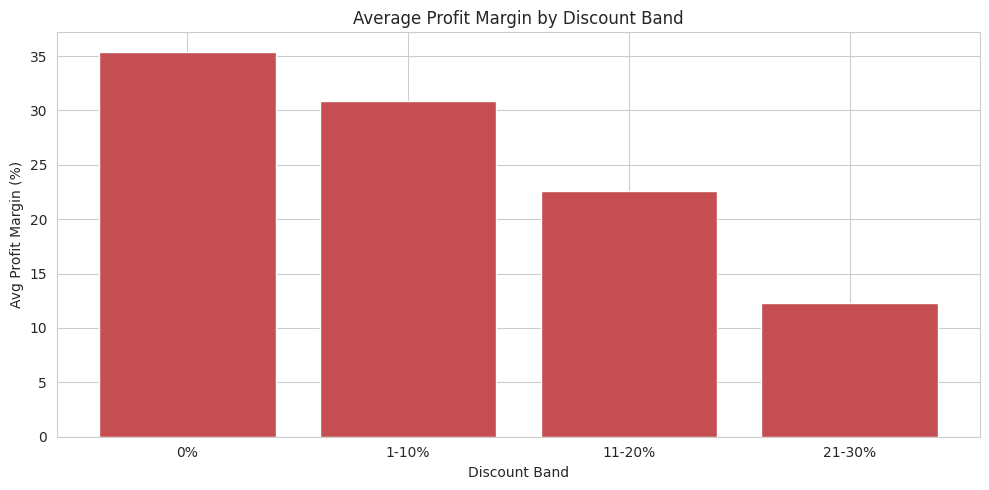

In [19]:
df_clean["Discount_Band"] = pd.cut(df_clean["Discount"], bins=[-0.01,0,0.1,0.2,0.31],
                                     labels=["0%","1-10%","11-20%","21-30%"])
disc_profit = df_clean.groupby("Discount_Band")["Profit_Margin"].mean().reset_index()

fig, ax = plt.subplots()
ax.bar(disc_profit["Discount_Band"].astype(str), disc_profit["Profit_Margin"]*100, color="#C44E52")
ax.set_title("Average Profit Margin by Discount Band")
ax.set_ylabel("Avg Profit Margin (%)")
ax.set_xlabel("Discount Band")
plt.tight_layout()
plt.show()

Yes, pretty clearly. Margin drops as the discount band goes up, and it's steepest in the 21-30% band. So deep discounts should probably be used sparingly, on slow-moving stock, not as a default sales tactic.

### Quantity vs revenue

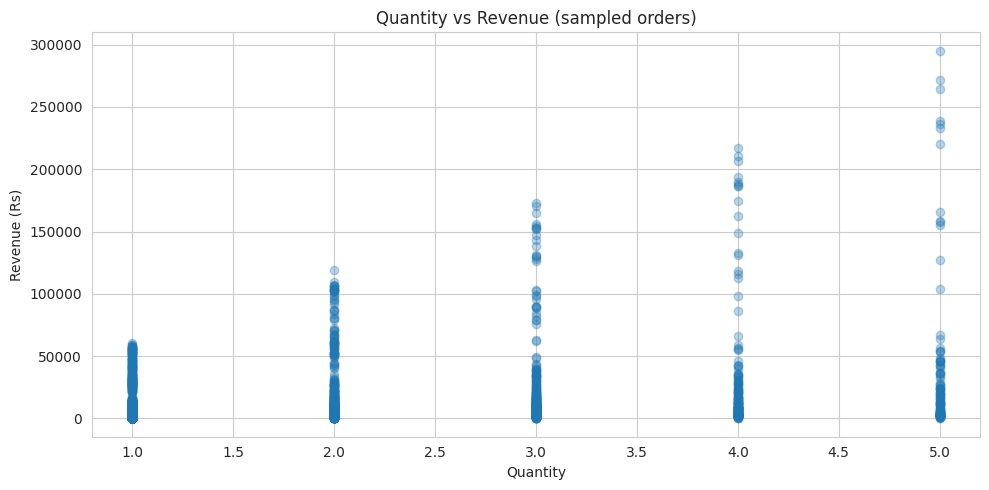

In [20]:
fig, ax = plt.subplots()
sample = df_clean.sample(min(3000, len(df_clean)), random_state=1)
ax.scatter(sample["Quantity"], sample["Revenue"], alpha=0.3)
ax.set_title("Quantity vs Revenue (sampled orders)")
ax.set_xlabel("Quantity"); ax.set_ylabel("Revenue (Rs)")
plt.tight_layout()
plt.show()

### Repeat vs new customers, share of revenue

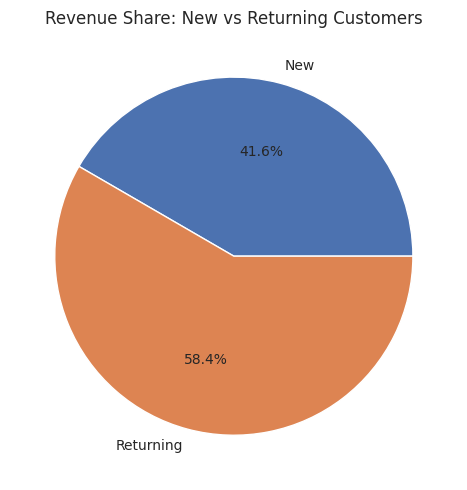

Customer_Type
New          41.64
Returning    58.36
Name: Revenue, dtype: float64

In [21]:
rev_share = df_clean.groupby("Customer_Type")["Revenue"].sum()
rev_share_pct = (rev_share / rev_share.sum() * 100).round(2)

fig, ax = plt.subplots()
ax.pie(rev_share_pct, labels=rev_share_pct.index, autopct="%1.1f%%", colors=["#4C72B0","#DD8452"])
ax.set_title("Revenue Share: New vs Returning Customers")
plt.tight_layout()
plt.show()
rev_share_pct

Returning customers punch above their weight here, contributing more revenue share than you'd expect from their numbers alone. Points toward retention being a better investment than pure acquisition for this business.

## Part 5: Customer-level analysis and RFM segmentation

Keeping the methodology simple here since this needs to be explainable in an interview:
- Recency: days since the customer's last order (lower is better, means more recently active)
- Frequency: number of distinct orders
- Monetary: total revenue from that customer

Each customer gets scored 1-4 (quartiles) on each of the three, and I average the scores to bucket people into High/Medium/Low value segments.

In [22]:
snapshot_date = df_clean["Order_Date"].max() + pd.Timedelta(days=1)

customer_agg = df_clean.groupby("Customer_ID").agg(
    Customer_Name=("Customer_Name","first"),
    Last_Order_Date=("Order_Date","max"),
    Frequency=("Order_ID","nunique"),
    Monetary=("Revenue","sum"),
).reset_index()

customer_agg["Recency"] = (snapshot_date - customer_agg["Last_Order_Date"]).dt.days
customer_agg["AOV"] = (customer_agg["Monetary"] / customer_agg["Frequency"]).round(2)

customer_agg.sort_values("Monetary", ascending=False).head(10)

,Customer_ID,Customer_Name,Last_Order_Date,Frequency,Monetary,Recency,AOV
585,CUST00594,Anika Sharma,2024-10-10,5,534555.14,83,106911.03
3776,CUST03826,Navya Nair,2024-08-26,8,448425.08,128,56053.13
3475,CUST03517,Saanvi Sharma,2024-11-04,8,447347.96,58,55918.50
430,CUST00438,Arjun Kumar,2024-11-13,8,445584.45,49,55698.06
3281,CUST03320,Navya Kumar,2024-10-19,6,432438.09,74,72073.02
688,CUST00698,Aarav Kapoor,2024-10-23,10,392016.33,70,39201.63
2981,CUST03017,Aadhya Joshi,2024-10-26,10,386383.59,67,38638.36
3598,CUST03643,Kiara Menon,2024-12-10,12,372012.37,22,31001.03
1796,CUST01818,Anika Iyer,2024-11-28,9,371530.31,34,41281.15
3340,CUST03380,Ayaan Kapoor,2024-12-05,8,370424.55,27,46303.07


In [23]:
# RFM scoring, 1 = worst, 4 = best
customer_agg["R_Score"] = pd.qcut(customer_agg["Recency"], 4, labels=[4,3,2,1]).astype(int)
customer_agg["F_Score"] = pd.qcut(customer_agg["Frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
customer_agg["M_Score"] = pd.qcut(customer_agg["Monetary"], 4, labels=[1,2,3,4]).astype(int)
customer_agg["RFM_Score"] = (customer_agg["R_Score"] + customer_agg["F_Score"] + customer_agg["M_Score"]) / 3

def segment(score):
    if score >= 3:
        return "High Value"
    elif score >= 2:
        return "Medium Value"
    else:
        return "Low Value"

customer_agg["Segment"] = customer_agg["RFM_Score"].apply(segment)
customer_agg["Segment"].value_counts()

Segment
High Value      1621
Medium Value    1508
Low Value       1018
Name: count, dtype: int64

In [24]:
seg_summary = customer_agg.groupby("Segment").agg(
    Customers=("Customer_ID","count"),
    Avg_Monetary=("Monetary","mean"),
    Avg_Frequency=("Frequency","mean"),
).round(2).sort_values("Avg_Monetary", ascending=False)
seg_summary

,Customers,Avg_Monetary,Avg_Frequency
Segment,,,
High Value,1621,93529.23,6.08
Medium Value,1508,43991.56,3.82
Low Value,1018,13293.99,2.27


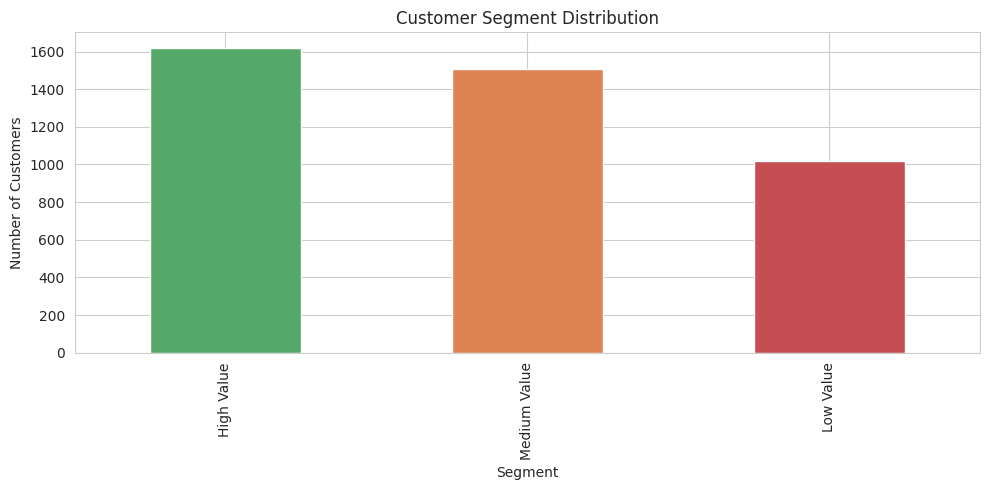

In [25]:
fig, ax = plt.subplots()
customer_agg["Segment"].value_counts().plot(kind="bar", color=["#55A868","#DD8452","#C44E52"], ax=ax)
ax.set_title("Customer Segment Distribution")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Repeat purchase rate

In [26]:
repeat_customers = (customer_agg["Frequency"] > 1).sum()
repeat_rate = repeat_customers / len(customer_agg) * 100
print(f"Repeat purchase rate: {repeat_rate:.2f}% ({repeat_customers} of {len(customer_agg)} customers)")

customer_agg.to_csv("../data/cleaned/customer_segments.csv", index=False)

Repeat purchase rate: 93.47% (3876 of 4147 customers)


## Part 6: Pulling the final numbers together

Just printing out the specific numbers I reference in `reports/business_insights.md`, so every claim in that report traces back to something computed here.

In [27]:
best_cat_revenue = cat_perf["Revenue"].idxmax()
best_cat_profit = cat_perf["Profit"].idxmax()
best_cat_margin = cat_perf["Profit_Margin_%"].idxmax()
worst_cat_margin = cat_perf["Profit_Margin_%"].idxmin()
best_region = region_perf["Revenue"].idxmax()
worst_region = region_perf["Revenue"].idxmin()
best_month = monthly.sort_values("Revenue", ascending=False).iloc[0]["Month"]
top_product_name = top10.reset_index().iloc[0]["Product_Name"]

print("Best category by revenue:", best_cat_revenue)
print("Best category by profit:", best_cat_profit)
print("Best category by margin:", best_cat_margin)
print("Worst category by margin:", worst_cat_margin)
print("Best region:", best_region)
print("Weakest region:", worst_region)
print("Best month:", best_month)
print("Top product:", top_product_name)
print("Repeat purchase rate: %.2f%%" % repeat_rate)
print("Overall profit margin: %.2f%%" % (overall_margin*100))

Best category by revenue: Electronics
Best category by profit: Electronics
Best category by margin: Beauty
Worst category by margin: Electronics
Best region: North
Weakest region: East
Best month: 2024-12
Top product: Smartphone Classic 11
Repeat purchase rate: 93.47%
Overall profit margin: 18.89%
